In [1]:
import sys
import os
# Add parent directory to path to import local modules
if '..' not in sys.path:
    sys.path.append('..')

import copy
from datetime import datetime
from einops import rearrange
import torch
from PIL import Image
import numpy as np
import skdim
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from my_ipadapter_model import load_ipadapter, image_grid, generate
from my_intrinsic_dim import get_intrinsic_dim
from dino_clip_featextract import extract_dino_image_embeds, extract_clip_image_embeds, dino_img_transform, clip_img_transform, img_transform_inv
from my_dino_correspondence import get_correspondence_plot, ncut_tsne_multiple_images, kway_cluster_per_image, kway_cluster_multiple_images, get_single_multi_discrete_rgbs, match_centers_three_images, match_centers_two_images, get_center_features
from compression_model_mkii import CompressionModel, train_compression_model, free_memory, get_fg_mask

plt.rcParams['font.family'] = 'monospace'

In [ ]:
def load_images_helper(pil_images):
    if isinstance(pil_images[0], str):
        pil_images = [Image.open(image) for image in pil_images]
    # convert to RGB
    pil_images = [image.convert("RGB") for image in pil_images]
    return pil_images

def train_mood_space(pos_images, lr=0.001, steps=5000, width=512, layers=4, dim=None, config_path="./config_base.yaml"): 
    pos_images = load_images_helper(pos_images)
    pos_dino_images = torch.stack([dino_img_transform(image) for image in pos_images])
    pos_clip_images = torch.stack([clip_img_transform(image) for image in pos_images])
    pos_dino_image_embeds = extract_dino_image_embeds(pos_dino_images) # (B, L, C)
    pos_clip_image_embeds = extract_clip_image_embeds(pos_clip_images) # (B, L, C)
    pos_neg_masks = torch.ones(pos_dino_image_embeds.shape[:-1], device=pos_dino_image_embeds.device)

    dino_image_embeds = pos_dino_image_embeds
    clip_image_embeds = pos_clip_image_embeds
    
    if dim is None:
        dim = get_intrinsic_dim(dino_image_embeds.flatten(end_dim=-2))
        dim = int(dim)
        print(f"intrinsic dim is {dim}")
    else:
        print(f"using user-specified dim: {dim}")

    cfg = OmegaConf.load(config_path)
    cfg.mood_dim = dim
    cfg.lr = lr
    cfg.steps = steps
    cfg.latent_dim = width
    cfg.n_layer = layers

    model = CompressionModel(cfg)
    trainer = train_compression_model(model, cfg, dino_image_embeds, clip_image_embeds, pos_neg_masks, compute_fg_mask=False)
    return model, trainer

def find_direction_two_images(image_embeds, eigvecs, A_to_B, unit_norm_direction=False):
    # image_embeds: A, B
    # eigvecs: A, B
    n_cluster = eigvecs[0].shape[-1]
    A_center_features = get_center_features(image_embeds[0], eigvecs[0].argmax(-1).cpu(), n_cluster=n_cluster)
    B_center_features = get_center_features(image_embeds[1], eigvecs[1].argmax(-1).cpu(), n_cluster=n_cluster)
    direction_A_to_B = []
    for i_A, i_B in enumerate(A_to_B):
        direction = B_center_features[i_B] - A_center_features[i_A]
        if unit_norm_direction:
            direction = direction / direction.norm(dim=-1, keepdim=True)
        direction_A_to_B.append(direction)
    direction_A_to_B = torch.stack(direction_A_to_B)

    cluster_labels = eigvecs[0].argmax(-1).cpu()
    n_cluster = eigvecs[0].shape[-1]
    direction_for_A = torch.zeros_like(image_embeds[0])
    for i_cluster in range(n_cluster):
        mask = cluster_labels == i_cluster
        if mask.sum() > 0:
            direction_for_A[mask] = direction_A_to_B[i_cluster]
    return direction_for_A

def interpolate_two_images(image1, image2, model, ws, n_cluster=20, match_method='hungarian', unit_norm_direction=False, dino_matching=True, seed=None):
    free_memory()
    images = torch.stack([dino_img_transform(image) for image in [image1, image2]])
    dino_image_embeds = extract_dino_image_embeds(images)
    compressed_image_embeds = model.compress(dino_image_embeds)
    input_embeds = dino_image_embeds
    _compressed_image_embeds = compressed_image_embeds
    original_images = images

    b, l, c = input_embeds.shape
    joint_eigvecs, joint_rgbs = ncut_tsne_multiple_images(input_embeds, n_eig=30, gamma=0.5)
    single_eigvecs = kway_cluster_per_image(input_embeds, n_cluster=n_cluster, gamma=0.5)

    A_to_B = match_centers_two_images(dino_image_embeds[0], dino_image_embeds[1], single_eigvecs[0], single_eigvecs[1], match_method=match_method)

    if dino_matching:
        direction = find_direction_two_images(_compressed_image_embeds, single_eigvecs, A_to_B, unit_norm_direction=unit_norm_direction)
    else:
        direction = _compressed_image_embeds[1] - _compressed_image_embeds[0]

    ip_model = load_ipadapter()
    
    n_steps = len(ws)
    interpolated_images = []
    for i_w, w in enumerate(ws):
        A_interpolated = _compressed_image_embeds[0] + direction * w
        A_interpolated = model.uncompress(A_interpolated)
        gen_images = generate(ip_model, A_interpolated, num_samples=1, seed=seed)
        interpolated_images.extend(gen_images)
    
    del ip_model
    free_memory()
    return interpolated_images, compressed_image_embeds, single_eigvecs, A_to_B

def compute_interpolation_scores(model, interpolated_images, compressed_image_embeds, single_eigvecs, A_to_B, ws, n_cluster=10, match_method='hungarian', verbose=True):
    """
    Compute interpolation scores with correspondence matching between clusters.
    
    Args:
        model: The compression model
        interpolated_images: List of interpolated PIL images
        compressed_image_embeds: Compressed embeddings of the source images
        single_eigvecs: Eigenvectors from clustering
        A_to_B: Matching between source and target clusters
        ws: Interpolation weights (tensor)
        n_cluster: Number of clusters to use (default: 10)
        match_method: Matching method for clusters (default: 'hungarian')
        verbose: Whether to print progress (default: True)
    
    Returns:
        all_step_scores: List of scores for each interpolation step
        uncompressed_embeds: Tensor of uncompressed embeddings for each step
        interpolated_clip_embeds: Tensor of CLIP embeddings from generated images
    """
    # Re-calculate direction for interpolation
    direction = find_direction_two_images(compressed_image_embeds, single_eigvecs, A_to_B, unit_norm_direction=False)
    
    # Get CLIP embeddings for interpolated images
    interpolated_images_transformed = torch.stack([clip_img_transform(img) for img in interpolated_images])
    interpolated_clip_embeds = extract_clip_image_embeds(interpolated_images_transformed)
    
    # Compute uncompressed embeddings for all steps
    uncompressed_embeds = []
    for i, w in enumerate(ws):
        A_interpolated = compressed_image_embeds[0] + direction * w
        uncompressed_clip_embed = model.uncompress(A_interpolated)
        uncompressed_embeds.append(uncompressed_clip_embed)
    uncompressed_embeds = torch.stack(uncompressed_embeds)
    
    # Compute scores with correspondence matching
    all_step_scores = []
    for i, w in enumerate(ws):
        # Get the embeddings for the current interpolation step
        uncompressed_embed = uncompressed_embeds[i].unsqueeze(0)  # Shape (1, L, C)
        generated_embed = interpolated_clip_embeds[i].unsqueeze(0)  # Shape (1, L, C)
        
        # Compute clusters for both embeddings
        uncompressed_eigvecs = kway_cluster_per_image(uncompressed_embed, n_cluster=n_cluster, gamma=0.5)
        generated_eigvecs = kway_cluster_per_image(generated_embed, n_cluster=n_cluster, gamma=0.5)
        
        # Match cluster centers
        A_to_B_matching = match_centers_two_images(
            uncompressed_embed.squeeze(0), 
            generated_embed.squeeze(0), 
            uncompressed_eigvecs.squeeze(0), 
            generated_eigvecs.squeeze(0), 
            match_method=match_method
        )
        
        # Get cluster centers
        uncompressed_centers = get_center_features(
            uncompressed_embed.squeeze(0), 
            uncompressed_eigvecs.squeeze(0).argmax(-1).cpu(), 
            n_cluster=n_cluster
        )
        generated_centers = get_center_features(
            generated_embed.squeeze(0), 
            generated_eigvecs.squeeze(0).argmax(-1).cpu(), 
            n_cluster=n_cluster
        )
        
        # Compute similarity between matching clusters
        cluster_scores = []
        for i_A, i_B in enumerate(A_to_B_matching):
            center_A = uncompressed_centers[i_A]
            center_B = generated_centers[i_B]
            score = torch.nn.functional.cosine_similarity(center_A, center_B, dim=0).item()
            cluster_scores.append(score)
        
        # Calculate overall score for this step
        overall_score = np.mean(cluster_scores)
        all_step_scores.append(overall_score)
        
        if verbose:
            print(f"w={w:.2f}, Matched Cluster Avg Score: {overall_score:.4f}")
    
    return all_step_scores, uncompressed_embeds, interpolated_clip_embeds

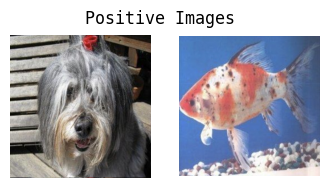

Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  8.15it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_preci

intrinsic dim is 10
Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 11.25it/s, v_num=237, loss/eigvec=9.25e-7, loss/recon_fg=0.00656, loss/axis_align=0.0301, loss/repulsion=0.580, loss/boundary=1.47e-5, loss/total=0.00663] 

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 11.15it/s, v_num=237, loss/eigvec=9.25e-7, loss/recon_fg=0.00656, loss/axis_align=0.0301, loss/repulsion=0.580, loss/boundary=1.47e-5, loss/total=0.00663]



In [3]:
# Load images for training
pos_image_paths = ["./images/dog1.jpg", "./images/fish.jpg"]
pos_images = load_images_helper(pos_image_paths)

# Display images
fig, axs = plt.subplots(1, len(pos_images), figsize=(len(pos_images) * 2, 2))
for i, img in enumerate(pos_images):
    axs[i].imshow(img)
    axs[i].axis('off')
plt.suptitle("Positive Images")
plt.show()

# Train the model
model, trainer = train_mood_space(pos_images, steps=1000)

Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  8.22it/s]

100%|██████████| 50/50 [00:01<00:00, 43.34it/s]

100%|██████████| 50/50 [00:01<00:00, 43.75it/s]

100%|██████████| 50/50 [00:01<00:00, 46.06it/s]

100%|██████████| 50/50 [00:01<00:00, 46.19it/s]

100%|██████████| 50/50 [00:01<00:00, 46.36it/s]

100%|██████████| 50/50 [00:01<00:00, 44.80it/s]

100%|██████████| 50/50 [00:01<00:00, 44.24it/s]

100%|██████████| 50/50 [00:01<00:00, 46.20it/s]

100%|██████████| 50/50 [00:01<00:00, 45.68it/s]

100%|██████████| 50/50 [00:01<00:00, 46.12it/s]

100%|██████████| 50/50 [00:01<00:00, 44.79it/s]



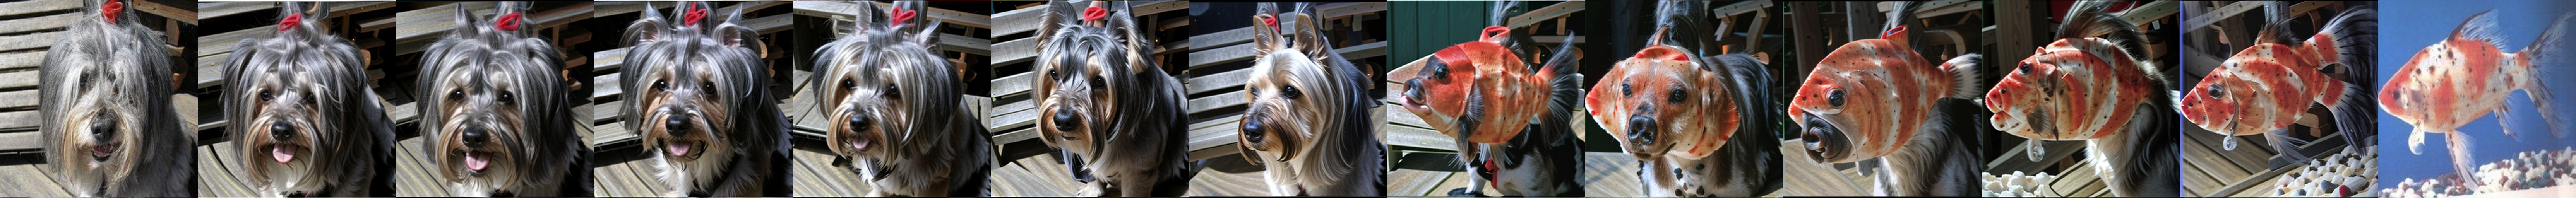

In [4]:
# Define images for interpolation

image1 = Image.open("./images/dog1.jpg").resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")
image2 = Image.open("./images/fish.jpg").resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")

# Define interpolation weights
ws = torch.linspace(0, 1, 11)

# Run interpolation
interpolated_images, compressed_image_embeds, single_eigvecs, A_to_B = interpolate_two_images(image1, image2, model, ws, n_cluster=10, match_method='hungarian')

# Display interpolated images
plot_images = [image1] + interpolated_images + [image2]
grid = image_grid(plot_images, 1, len(plot_images))
grid

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  8.84it/s]


w=0.00, Matched Cluster Avg Score: 0.6467
w=0.10, Matched Cluster Avg Score: 0.5863
w=0.20, Matched Cluster Avg Score: 0.6377
w=0.30, Matched Cluster Avg Score: 0.6213
w=0.40, Matched Cluster Avg Score: 0.5881
w=0.50, Matched Cluster Avg Score: 0.5380
w=0.60, Matched Cluster Avg Score: 0.5452
w=0.70, Matched Cluster Avg Score: 0.3975
w=0.80, Matched Cluster Avg Score: 0.5029
w=0.90, Matched Cluster Avg Score: 0.4236
w=1.00, Matched Cluster Avg Score: 0.5683


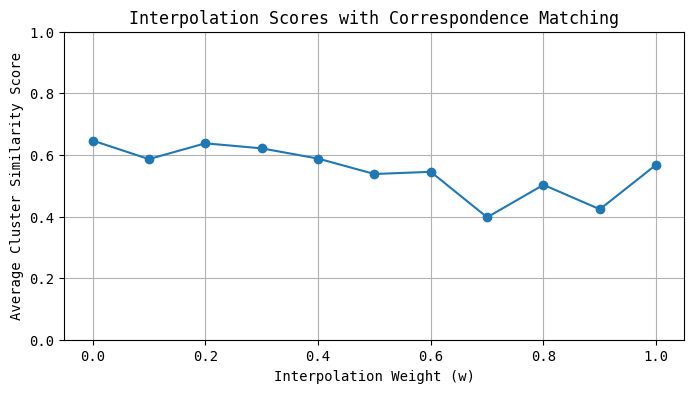

In [5]:
all_step_scores, uncompressed_embeds, interpolated_clip_embeds = compute_interpolation_scores(
    model, 
    interpolated_images, 
    compressed_image_embeds, 
    single_eigvecs, 
    A_to_B, 
    ws, 
    n_cluster=10, 
    match_method='hungarian', 
    verbose=True
)

# Plot interpolation scores
plt.figure(figsize=(8, 4))
plt.plot(ws.numpy(), all_step_scores, marker='o')
plt.title("Interpolation Scores with Correspondence Matching")
plt.xlabel("Interpolation Weight (w)")
plt.ylabel("Average Cluster Similarity Score")
plt.ylim(0, 1)
plt.grid()
plt.show()

Lowest score at step 7, w=0.70, score=0.3975


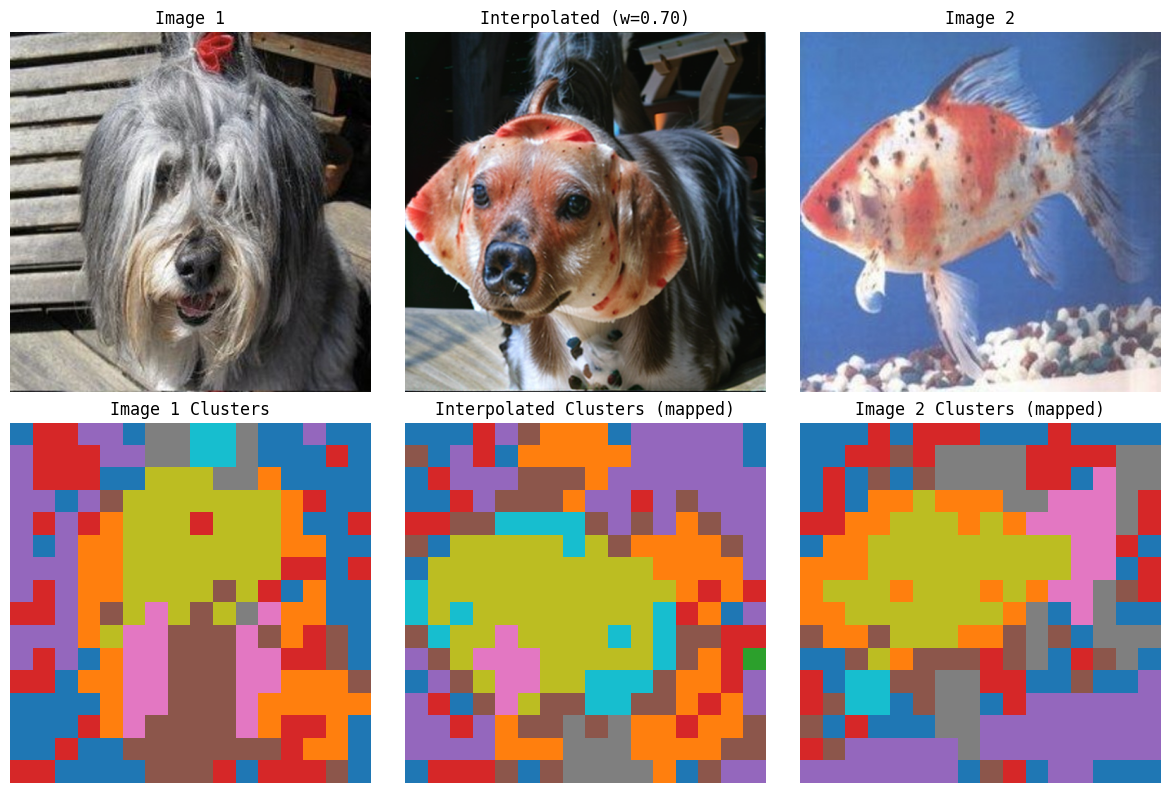

In [6]:
# Visualize clusters for image1, image2, and an interpolated image

# Choose the interpolation step with the lowest clip score
min_score_idx = all_step_scores.index(min(all_step_scores))
i_step = min_score_idx
w_step = ws[i_step]
interpolated_image_to_viz = interpolated_images[i_step]
print(f"Lowest score at step {i_step}, w={w_step:.2f}, score={all_step_scores[i_step]:.4f}")

# Get the embeddings for image1, image2, and the interpolated image
image1_clip_embed = model.uncompress(compressed_image_embeds[0]).unsqueeze(0)
image2_clip_embed = model.uncompress(compressed_image_embeds[1]).unsqueeze(0)
interpolated_clip_embed_viz = interpolated_clip_embeds[i_step].unsqueeze(0)

# Compute clusters
n_cluster_viz = 10 # Same as in the previous cell
image1_eigvecs = kway_cluster_per_image(image1_clip_embed, n_cluster=n_cluster_viz, gamma=0.5)
image2_eigvecs = kway_cluster_per_image(image2_clip_embed, n_cluster=n_cluster_viz, gamma=0.5)
interpolated_eigvecs = kway_cluster_per_image(interpolated_clip_embed_viz, n_cluster=n_cluster_viz, gamma=0.5)

# Match clusters between image1 and image2
match_1_to_2 = match_centers_two_images(image1_clip_embed.squeeze(0), image2_clip_embed.squeeze(0), image1_eigvecs.squeeze(0), image2_eigvecs.squeeze(0), match_method='hungarian')

# Match clusters between image1 and the interpolated image
match_1_to_interp = match_centers_two_images(image1_clip_embed.squeeze(0), interpolated_clip_embed_viz.squeeze(0), image1_eigvecs.squeeze(0), interpolated_eigvecs.squeeze(0), match_method='hungarian')

# Get cluster labels
cluster_labels1 = image1_eigvecs.argmax(-1).squeeze(0)
cluster_labels2 = image2_eigvecs.argmax(-1).squeeze(0)
cluster_labels_interp = interpolated_eigvecs.argmax(-1).squeeze(0)

# Reshape for visualization
h = w = int(np.sqrt(cluster_labels1[1:].shape[0]))
cluster_map1 = cluster_labels1[1:].reshape(h, w).cpu().numpy()
cluster_map2 = cluster_labels2[1:].reshape(h, w).cpu().numpy()
cluster_map_interp = cluster_labels_interp[1:].reshape(h, w).cpu().numpy()

# Create mapped cluster images for consistent coloring
cluster_map2_mapped = np.zeros_like(cluster_map2)
for i_A, i_B in enumerate(match_1_to_2):
    cluster_map2_mapped[cluster_map2 == i_B] = i_A

cluster_map_interp_mapped = np.zeros_like(cluster_map_interp)
for i_A, i_B in enumerate(match_1_to_interp):
    cluster_map_interp_mapped[cluster_map_interp == i_B] = i_A

# Plotting
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
cmap = 'tab10'

# Row 1: Original Images
axs[0, 0].imshow(image1)
axs[0, 0].set_title('Image 1')
axs[0, 0].axis('off')

axs[0, 1].imshow(interpolated_image_to_viz)
axs[0, 1].set_title(f'Interpolated (w={w_step:.2f})')
axs[0, 1].axis('off')

axs[0, 2].imshow(image2)
axs[0, 2].set_title('Image 2')
axs[0, 2].axis('off')

# Row 2: Images with Cluster Overlays
axs[1, 0].imshow(image1)
axs[1, 0].imshow(cluster_map1, cmap=cmap, interpolation='nearest')
axs[1, 0].set_title('Image 1 Clusters')
axs[1, 0].axis('off')

axs[1, 1].imshow(interpolated_image_to_viz)
axs[1, 1].imshow(cluster_map_interp_mapped, cmap=cmap, interpolation='nearest')
axs[1, 1].set_title('Interpolated Clusters (mapped)')
axs[1, 1].axis('off')

axs[1, 2].imshow(image2)
axs[1, 2].imshow(cluster_map2_mapped, cmap=cmap, interpolation='nearest')
axs[1, 2].set_title('Image 2 Clusters (mapped)')
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()